# Grover's Algorithm

/var/folders/p8/wytng6t53dl_gcrnlz01_zn00000gn/T/ipykernel_1422/1001872461.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


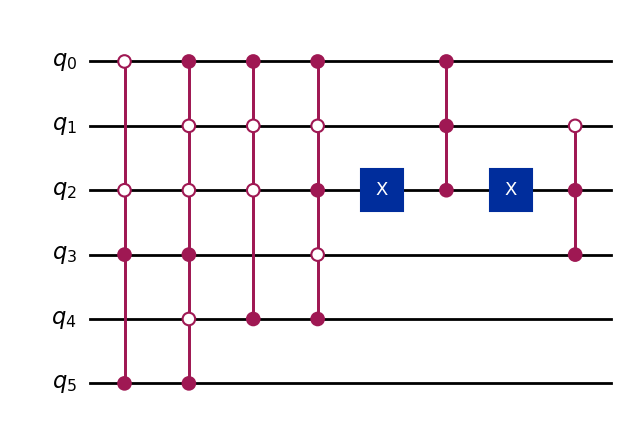

In [1]:
from qiskit import QuantumCircuit
from qiskit_algorithms import AmplificationProblem
from qiskit.circuit.library import PhaseOracle

log_expr = '((Ben & Lia) | (Martin & Mia) | (Ben & Feyling) | (Jack & Mia)) & ~(Lia & Martin)'
oracle = PhaseOracle(expression=log_expr, var_order=["Ben", "Lia", "Martin", "Mia", "Feyling", "Jack"])
display(oracle.draw("mpl"))

# define Grover's algorithm
problem = AmplificationProblem(oracle)

# now we can have a look at the Grover operator that is used in running the algorithm
# (Algorithm circuits are wrapped in a gate to appear in composition as a block
# so we have to decompose() the op to see it expanded into its component gates.)
# problem.grover_operator.draw(output="mpl")

In [2]:
from qiskit import QuantumCircuit
from qiskit_algorithms import AmplificationProblem
from qiskit_algorithms import Grover
from qiskit_aer.primitives import Sampler


grover = Grover(sampler=Sampler())
result = grover.amplify(problem)
print("Result type:", type(result))
print()
print("Success!" if result.oracle_evaluation else "Failure!")
print("Top measurement:", result.top_measurement)

Result type: <class 'qiskit_algorithms.amplitude_amplifiers.grover.GroverResult'>

Failure!
Top measurement: 101110


In [ ]:
from __future__ import annotations

import itertools
from collections.abc import Iterator, Generator
from typing import Any, Callable, List, cast

import numpy as np

from qiskit import ClassicalRegister, QuantumCircuit
from qiskit.primitives import BaseSamplerV1 as BaseSampler
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import GroverOperator as _QiskitGroverOperator

from qiskit_algorithms.exceptions import AlgorithmError
from qiskit_algorithms.utils import algorithm_globals

class AmplificationProblem:
    """Container describing the amplitude amplification problem for Grover."""

    def __init__(
        self,
        oracle: QuantumCircuit | Statevector,
        state_preparation: QuantumCircuit | None = None,
        grover_operator: QuantumCircuit | None = None,
        post_processing: Callable[[str], Any] | None = None,
        objective_qubits: int | list[int] | None = None,
        is_good_state: Callable[[str], bool] | list[int] | list[str] | Statevector | None = None,
    ) -> None:
        self._oracle = oracle
        self._state_preparation = state_preparation
        self._grover_operator = grover_operator
        self._post_processing = post_processing
        self._objective_qubits = objective_qubits

        if is_good_state is not None:
            self._is_good_state = is_good_state
        elif hasattr(oracle, "evaluate_bitstring"):
            self._is_good_state = oracle.evaluate_bitstring
        else:
            self._is_good_state = None

    # --- oracle ---
    @property
    def oracle(self) -> QuantumCircuit | Statevector:
        return self._oracle

    @oracle.setter
    def oracle(self, oracle: QuantumCircuit | Statevector) -> None:
        self._oracle = oracle

    # --- state preparation ---
    @property
    def state_preparation(self) -> QuantumCircuit:
        if self._state_preparation is None:
            sp = QuantumCircuit(self.oracle.num_qubits)
            sp.h(sp.qubits)
            return sp
        return self._state_preparation

    @state_preparation.setter
    def state_preparation(self, state_preparation: QuantumCircuit | None) -> None:
        self._state_preparation = state_preparation

    # --- post processing ---
    @property
    def post_processing(self) -> Callable[[str], Any]:
        return self._post_processing or (lambda x: x)

    @post_processing.setter
    def post_processing(self, post_processing: Callable[[str], Any]) -> None:
        self._post_processing = post_processing

    # --- objective qubits ---
    @property
    def objective_qubits(self) -> list[int]:
        if self._objective_qubits is None:
            return list(range(self.oracle.num_qubits))
        if isinstance(self._objective_qubits, int):
            return [self._objective_qubits]
        return self._objective_qubits

    @objective_qubits.setter
    def objective_qubits(self, objective_qubits: int | list[int] | None) -> None:
        self._objective_qubits = objective_qubits

    # --- is_good_state ---
    @property
    def is_good_state(self) -> Callable[[str], bool] | None:
        if (self._is_good_state is None) or callable(self._is_good_state):
            return self._is_good_state

        # If list provided, accept either list[str] or list[int] semantics
        if isinstance(self._is_good_state, list):
            if all(isinstance(s, str) for s in self._is_good_state):
                good = cast(List[str], self._is_good_state)
                return lambda bitstr: bitstr in good
            idxs = cast(List[int], self._is_good_state)
            return lambda bitstr: all(bitstr[i] == "1" for i in idxs)

        # If Statevector provided
        sv = cast(Statevector, self._is_good_state)
        good_set = set(sv.probabilities_dict().keys())
        return lambda bitstr: bitstr in good_set

    @is_good_state.setter
    def is_good_state(
        self, is_good_state: Callable[[str], bool] | list[int] | list[str] | Statevector
    ) -> None:
        self._is_good_state = is_good_state

    # --- grover operator ---
    @property
    def grover_operator(self) -> QuantumCircuit:
        if self._grover_operator is None:
            return _QiskitGroverOperator(self.oracle, self.state_preparation)
        return self._grover_operator

    @grover_operator.setter
    def grover_operator(self, grover_operator: QuantumCircuit | None) -> None:
        self._grover_operator = grover_operator


class GroverResult:
    """Result object for Grover."""

    def __init__(self) -> None:
        self._iterations: list[int] | None = None
        self._top_measurement: str | None = None
        self._assignment: Any = None
        self._oracle_evaluation: bool | None = None
        self._circuit_results: list[dict[str, Any]] | None = None
        self._max_probability: float | None = None

    # iterations tried
    @property
    def iterations(self) -> list[int] | None:
        return self._iterations

    @iterations.setter
    def iterations(self, value: list[int]) -> None:
        self._iterations = value

    # top measurement
    @property
    def top_measurement(self) -> str | None:
        return self._top_measurement

    @top_measurement.setter
    def top_measurement(self, value: str) -> None:
        self._top_measurement = value

    # post-processed assignment
    @property
    def assignment(self) -> Any:
        return self._assignment

    @assignment.setter
    def assignment(self, value: Any) -> None:
        self._assignment = value

    # oracle evaluation of top measurement
    @property
    def oracle_evaluation(self) -> bool | None:
        return self._oracle_evaluation

    @oracle_evaluation.setter
    def oracle_evaluation(self, value: bool | None) -> None:
        self._oracle_evaluation = value

    # raw circuit results
    @property
    def circuit_results(self) -> list[dict[str, Any]] | None:
        return self._circuit_results

    @circuit_results.setter
    def circuit_results(self, value: list[dict[str, Any]]) -> None:
        self._circuit_results = value

    # maximum probability observed
    @property
    def max_probability(self) -> float | None:
        return self._max_probability

    @max_probability.setter
    def max_probability(self, value: float | None) -> None:
        self._max_probability = value


class Grover:
    r"""Grover's Search algorithm (direct implementation).

    The logic matches the Qiskit Algorithms behavior: it supports fixed/list/iterator iterations,
    optional geometric growth via ``growth_rate``, optional sampling within ranges, and uses a
    Sampler to run circuits.
    """

    def __init__(
        self,
        iterations: list[int] | Iterator[int] | int | None = None,
        growth_rate: float | None = None,
        sample_from_iterations: bool = False,
        sampler: BaseSampler | None = None,
    ) -> None:
        # default: geometric growth
        if growth_rate is None and iterations is None:
            growth_rate = 1.2

        if growth_rate is not None and iterations is not None:
            raise ValueError("Pass either a value for iterations or growth_rate, not both.")

        if growth_rate is not None:
            # generate int(growth_rate ** k) for k >= 1
            self._iterations: Generator[int, None, None] | list[int] = (
                int(growth_rate**x) for x in itertools.count(1)
            )
        elif isinstance(iterations, int):
            self._iterations = [iterations]
        else:
            self._iterations = iterations  # type: ignore[assignment]

        self._sampler = sampler
        self._sample_from_iterations = sample_from_iterations
        self._iterations_arg = iterations

    # sampler getter/setter for parity with upstream API
    @property
    def sampler(self) -> BaseSampler | None:
        return self._sampler

    @sampler.setter
    def sampler(self, sampler: BaseSampler) -> None:
        self._sampler = sampler

    # ----------------- public API -----------------
    def amplify(self, amplification_problem: AmplificationProblem) -> GroverResult:
        """Run Grover for the provided problem."""
        if self._sampler is None:
            raise ValueError("A sampler must be provided.")

        # max iterations/power logic mirrors upstream behavior
        if isinstance(self._iterations, list):
            max_iterations = len(self._iterations)
            max_power = np.inf
            iterator: Iterator[int] = iter(self._iterations)
        else:
            max_iterations = max(10, 2**amplification_problem.oracle.num_qubits)
            max_power = np.ceil(
                2 ** (len(amplification_problem.grover_operator.reflection_qubits) / 2)
            )
            iterator = self._iterations

        result = GroverResult()

        iterations: list[int] = []
        top_measurement = "0" * len(amplification_problem.objective_qubits)
        oracle_evaluation: bool | None = False
        all_circuit_results: list[dict[str, Any]] = []
        max_probability = 0.0

        for _ in range(max_iterations):
            # next power
            power = next(iterator)
            if power > max_power:
                break

            iterations.append(power)

            # optionally sample random power in [0, power)
            eff_power = (
                int(algorithm_globals.random.integers(power)) if self._sample_from_iterations else power
            )

            # build circuit with *effective* power
            qc = self.construct_circuit(amplification_problem, eff_power, measurement=True)

            # run
            job = self._sampler.run([qc])
            try:
                results = job.result()
            except Exception as exc:
                raise AlgorithmError("Sampler job failed.") from exc

            num_bits = len(amplification_problem.objective_qubits)
            quasi = results.quasi_dists[0]
            circuit_results: dict[str, Any] = {np.binary_repr(k, num_bits): v for k, v in quasi.items()}
            top_measurement, max_probability = max(circuit_results.items(), key=lambda x: x[1])  # type: ignore[assignment]

            all_circuit_results.append(circuit_results)

            # If user passed a single integer for iterations and no is_good_state, we cannot check
            if (isinstance(self._iterations_arg, int)) and (amplification_problem.is_good_state is None):
                oracle_evaluation = None
                break

            # For non-int iterations, require is_good_state
            if (
                self._iterations_arg is None or isinstance(self._iterations_arg, list)
            ) and amplification_problem.is_good_state is None:
                raise TypeError("An is_good_state function is required with the provided oracle")

            # evaluate classical oracle on the winning bitstring
            if amplification_problem.is_good_state is not None:
                oracle_evaluation = amplification_problem.is_good_state(top_measurement)  # type: ignore[operator]

            if oracle_evaluation is True:
                break  # found a solution

        # package result
        result.iterations = iterations
        result.top_measurement = top_measurement
        result.assignment = amplification_problem.post_processing(top_measurement)
        result.oracle_evaluation = oracle_evaluation
        result.circuit_results = all_circuit_results
        result.max_probability = max_probability

        return result

    @staticmethod
    def optimal_num_iterations(num_solutions: int, num_qubits: int) -> int:
        """Return the optimal number of Grover iterations given k solutions on n qubits."""
        amplitude = np.sqrt(num_solutions / 2**num_qubits)
        return round(np.arccos(amplitude) / (2 * np.arcsin(amplitude)))

    def construct_circuit(
        self, problem: AmplificationProblem, power: int | None = None, measurement: bool = False
    ) -> QuantumCircuit:
        """Construct the Grover circuit with ``power`` Grover operators."""
        if power is None:
            # if user didn't pass a power, accept only the single-int case
            if not isinstance(self._iterations, list) or len(self._iterations) != 1:
                raise ValueError("Please pass ``power`` if the iterations are not an integer.")
            power = self._iterations[0]  # type: ignore[index]

        qc = QuantumCircuit(problem.oracle.num_qubits, name="Grover circuit")
        qc.compose(problem.state_preparation, inplace=True)
        if power > 0:
            qc.compose(problem.grover_operator.power(power), inplace=True)

        if measurement:
            measurement_cr = ClassicalRegister(len(problem.objective_qubits))
            qc.add_register(measurement_cr)
            qc.measure(problem.objective_qubits, measurement_cr)

        return qc


from qiskit import QuantumCircuit
from qiskit_algorithms import AmplificationProblem
from qiskit.circuit.library import PhaseOracle

log_expr = '((Ben & Lia) | (Martin & Mia) | (Ben & Feyling) | (Jack & Mia)) & ~(Lia & Martin)'
oracle = PhaseOracle(expression=log_expr, var_order=["Ben", "Lia", "Martin", "Mia", "Feyling", "Jack"])

# define Grover's algorithm
problem = AmplificationProblem(oracle)


from qiskit_aer.primitives import Sampler


grover = Grover(sampler=Sampler())
result = grover.amplify(problem)
print("Result type:", type(result))
print()
print("Success!" if result.oracle_evaluation else "Failure!")
print("Top measurement:", result.top_measurement)

Ben, Lia, Martin, Mia, Feyling, Jack = list([int(_) for _ in result.top_measurement[::-1]])
print(((Ben & Lia) | (Martin & Mia) | (Ben & Feyling) | (Jack & Mia)) & ~(Lia & Martin))

Result type: <class '__main__.GroverResult'>

Success!
Top measurement: 111010
1
